In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models #type: ignore
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
#Load Data
cols = ['unit', 'cycle', 'os1', 'os2', 'os3'] + [f's{i}' for i in range(1, 22)]

def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(
        path, sep=' +', header=None,
        usecols=range(26), names=cols, engine='python'
    )

train = load_data('../Dataset/train_FD004.txt')
test  = load_data('../Dataset/test_FD004.txt')
rul   = pd.read_csv('../Dataset/RUL_FD004.txt', header=None, names=['rul'])

In [3]:
train.head()

,unit,cycle,os1,os2,os3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    61249 non-null  int64  
 1   cycle   61249 non-null  int64  
 2   os1     61249 non-null  float64
 3   os2     61249 non-null  float64
 4   os3     61249 non-null  float64
 5   s1      61249 non-null  float64
 6   s2      61249 non-null  float64
 7   s3      61249 non-null  float64
 8   s4      61249 non-null  float64
 9   s5      61249 non-null  float64
 10  s6      61249 non-null  float64
 11  s7      61249 non-null  float64
 12  s8      61249 non-null  float64
 13  s9      61249 non-null  float64
 14  s10     61249 non-null  float64
 15  s11     61249 non-null  float64
 16  s12     61249 non-null  float64
 17  s13     61249 non-null  float64
 18  s14     61249 non-null  float64
 19  s15     61249 non-null  float64
 20  s16     61249 non-null  float64
 21  s17     61249 non-null  int64  
 22  s18     6

In [5]:
#Droping unimportant features based on EDA and domain knowledge
DROP_SENSORS = ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']
DROP_SETTINGS = ['os3']  # single value in FD001/FD003; keep for FD002/FD004

KEEP_SENSORS = ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']

train.drop(columns=DROP_SENSORS + DROP_SETTINGS, inplace=True)
test.drop(columns=DROP_SENSORS + DROP_SETTINGS, inplace=True)

In [6]:
#compute RUL for training data
def add_rul(df: pd.DataFrame) -> pd.DataFrame:
    max_cycle = df.groupby('unit')['cycle'].transform('max')
    df['RUL'] = max_cycle - df['cycle']
    return df

train = add_rul(train)

In [7]:
#For the test set, RUL at the last cycle
last_cycles = test.groupby('unit')['cycle'].max().reset_index()
last_cycles['RUL'] = rul['rul'].values
test = test.merge(last_cycles[['unit', 'RUL']], on='unit', how='left')
# Keep only the last cycle row per engine for evaluation
test_last = test.groupby('unit').last().reset_index()

In [8]:
#Rul clipping to handle outliers and focus on near-term predictions
RUL_CLIP = 125  # standard choice for C-MAPSS; tune per dataset

train['RUL'] = train['RUL'].clip(upper=RUL_CLIP)

In [9]:
train['condition'] = train[['os1','os2']].round(2).astype(str).agg('_'.join, axis=1)
test['condition']  = test[['os1','os2']].round(2).astype(str).agg('_'.join, axis=1)

train[KEEP_SENSORS] = train[KEEP_SENSORS].astype(float)
test[KEEP_SENSORS]  = test[KEEP_SENSORS].astype(float)

In [10]:
scalers = {}

# fit per condition
for cond in train['condition'].unique():
    scaler = MinMaxScaler()
    
    idx = train['condition'] == cond
    train.loc[idx, KEEP_SENSORS] = scaler.fit_transform(train.loc[idx, KEEP_SENSORS])
    
    scalers[cond] = scaler

# apply to test
for cond, scaler in scalers.items():
    idx = test['condition'] == cond
    if idx.sum() > 0:
        test.loc[idx, KEEP_SENSORS] = scaler.transform(test.loc[idx, KEEP_SENSORS])

In [11]:
WINDOW = 30
FEATURES = KEEP_SENSORS

def build_sequences(df, feature_cols, window=WINDOW):
    X, y = [], []
    
    for _, engine_df in df.groupby('unit'):
        engine_df = engine_df.sort_values('cycle')
        
        data = engine_df[feature_cols].values
        labels = engine_df['RUL'].values
        
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])
            y.append(labels[i+window-1])
    
    return np.array(X), np.array(y)

def build_last_sequences(df, feature_cols, window=WINDOW):
    X, y = [], []
    for _, engine_df in df.groupby('unit'):
        engine_df = engine_df.sort_values('cycle')
        data = engine_df[feature_cols].values
        label = engine_df['RUL'].iloc[-1]
        if len(data) >= window:
            X.append(data[-window:])
        else:
            pad = np.zeros((window - len(data), len(feature_cols)))
            X.append(np.vstack([pad, data]))
        y.append(label)
    return np.array(X), np.array(y)


In [12]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(train, groups=train['unit']))

df_train = train.iloc[train_idx]
df_val   = train.iloc[val_idx]

In [13]:
X_train_seq, y_train_seq = build_sequences(df_train, KEEP_SENSORS, WINDOW)
X_val_seq, y_val_seq     = build_sequences(df_val, KEEP_SENSORS, WINDOW)
X_test_seq, y_test_seq = build_last_sequences(test, KEEP_SENSORS, WINDOW)

In [14]:
RUL_MAX = 125

X_train_seq = X_train_seq.astype(np.float32)
X_val_seq   = X_val_seq.astype(np.float32)
X_test_seq  = X_test_seq.astype(np.float32)

y_train_seq = y_train_seq / RUL_MAX
y_val_seq   = y_val_seq / RUL_MAX

y_test_seq  = y_test_seq / RUL_MAX

In [15]:
model = models.Sequential([
    layers.GRU(64, return_sequences=True, input_shape=(WINDOW, len(KEEP_SENSORS))),
    layers.Dropout(0.2),
    layers.GRU(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

x:\nasim_xhqpjmy\Code\MLops\Aircraft-engine-Main\Real-Time-Aircraft-Engine-Predictive-Maintenance-System\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,737 (96.63 KB)

 Trainable params: 24,737 (96.63 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [19]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=20,
    batch_size=128
)

Epoch 1/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0545 - root_mean_squared_error: 0.2334 - val_loss: 0.0352 - val_root_mean_squared_error: 0.1877
Epoch 2/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0299 - root_mean_squared_error: 0.1728 - val_loss: 0.0309 - val_root_mean_squared_error: 0.1757
Epoch 3/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0260 - root_mean_squared_error: 0.1613 - val_loss: 0.0322 - val_root_mean_squared_error: 0.1795
Epoch 4/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0227 - root_mean_squared_error: 0.1506 - val_loss: 0.0256 - val_root_mean_squared_error: 0.1600
Epoch 5/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0203 - root_mean_squared_error: 0.1424 - val_loss: 0.0298 - val_root_mean_squared_error: 0.1727
Epoch 6/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0190 - root_mean_squared_error: 0.1378 - val_loss: 0.0234 - val_root_mean_squared_error: 0.1529
Epoch 7/20
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s

In [20]:
val_preds = model.predict(X_val_seq) * RUL_MAX

y_val_true = y_val_seq * RUL_MAX
rmse_val = np.sqrt(mean_squared_error(y_val_true, val_preds))

print(f"Validation RMSE: {rmse_val:.2f}")

329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Validation RMSE: 17.53


In [21]:
X_test_seq = X_test_seq.astype(np.float32)
y_test_seq = y_test_seq.astype(np.float32)

In [22]:
test_preds = model.predict(X_test_seq) * RUL_MAX

y_test_true = y_test_seq * RUL_MAX
rmse_test = np.sqrt(mean_squared_error(y_test_true, test_preds))
print(f"Test RMSE: {rmse_test:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test RMSE: 33.34


In [23]:
print(test_last.shape)      # should be (100, ...)
print(test_preds.shape)

(248, 16)
(248, 1)


In [24]:
results = pd.DataFrame({
    'unit': test_last['unit'].values,
    'true_RUL': test_last['RUL'].values,
    'pred_RUL': test_preds.flatten()
})
results.head(10)


,unit,true_RUL,pred_RUL
0,1,22,30.603188
1,2,39,40.211037
2,3,107,116.397041
3,4,75,87.976967
4,5,149,98.017967
5,6,78,81.247246
6,7,94,98.213837
7,8,14,18.246679
8,9,99,119.206833
9,10,162,57.056637


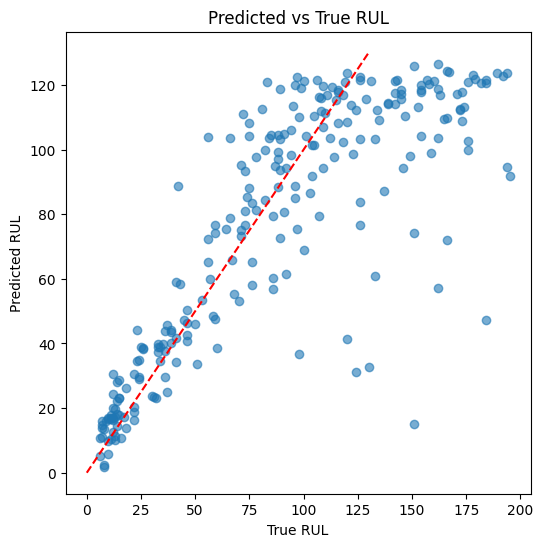

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(results['true_RUL'], results['pred_RUL'], alpha=0.6)
plt.plot([0, 130], [0, 130], 'r--')  # ideal line
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.show()

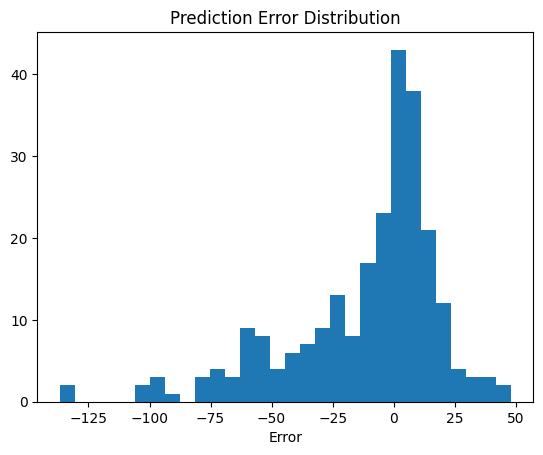

In [26]:
results['error'] = results['pred_RUL'] - results['true_RUL']

plt.hist(results['error'], bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.show()

In [27]:
results['abs_error'] = results['error'].abs()

worst = results.sort_values(by='abs_error', ascending=False).head(10)
worst

,unit,true_RUL,pred_RUL,error,abs_error
124,125,184,47.281876,-136.718124,136.718124
203,204,151,14.931618,-136.068382,136.068382
9,10,162,57.056637,-104.943363,104.943363
126,127,195,91.754272,-103.245728,103.245728
18,19,194,94.483574,-99.516426,99.516426
140,141,130,32.775372,-97.224628,97.224628
238,239,166,72.043381,-93.956619,93.956619
27,28,124,31.121248,-92.878752,92.878752
228,229,120,41.268745,-78.731255,78.731255
38,39,151,74.331970,-76.668030,76.668030


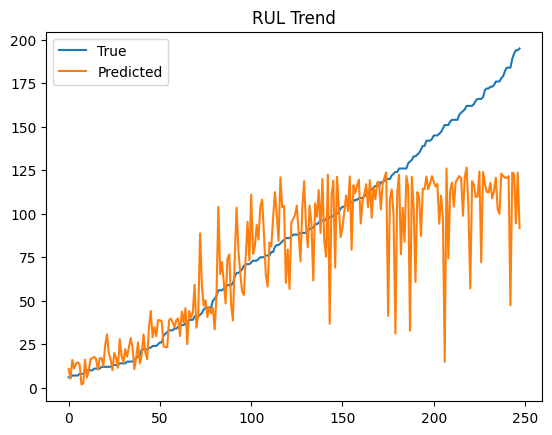

In [28]:
results_sorted = results.sort_values(by='true_RUL')

plt.plot(results_sorted['true_RUL'].values, label='True')
plt.plot(results_sorted['pred_RUL'].values, label='Predicted')
plt.legend()
plt.title("RUL Trend")
plt.show()

In [29]:
results['critical_true'] = results['true_RUL'] < 30
results['critical_pred'] = results['pred_RUL'] < 30

from sklearn.metrics import confusion_matrix

confusion_matrix(results['critical_true'], results['critical_pred'])

array([[190,   6],
       [  8,  44]])